# Автоматична детекція, відокремлення та парсинг OSD з відеопотоку БПЛА

Покроковий запуск двостадійного пайплайну на одному відео з папки `videos/`:

1. **Модель 1 — детекція bbox**: 3 рівномірні кадри → координатна сітка 0–1000 без падінгів → few-shot приклади + кадри → VLM → один набір bbox OSD-елементів на все відео (OSD статичний, сцена рухається).
2. **Модель 2 — парсинг значень**: ті самі кадри з нанесеними (напівпрозорими) bbox вибраного рану моделі 1 + каталог назв bbox → VLM → значення 25 фіксованих ключів телеметрії по кожному кадру; bbox фільтруються до тих, з яких зчитано значення.

Обидві моделі викликаються через OpenRouter (`osd/openrouter.py`) у `N` паралельних запитах; `FIRST_ONLY=True` — повернути перший успішний ран і не чекати решту.

## 1. Параметри та вхідне відео

📁 відео у videos/: 16
🤖 модель 1: qwen/qwen3.8-flash (reasoning=low) × 5 · модель 2: qwen/qwen3.8-flash (reasoning=low) × 3 · FIRST_ONLY=False
вхідне відео · rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk.mp4: 1152×720, 56.2 с, 30.0 fps · GIF прискорено ×7.5
🎞️ rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk.gif: 1111 KB


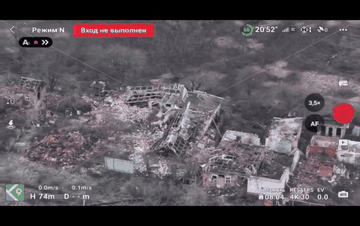

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "osd").exists() else Path.cwd() / "final_solution"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%config InlineBackend.figure_formats = ["jpeg"]
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.dpi": 100})
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 220)

from osd import constants as C
from osd.bbox_video import show_video_gif
from osd.extract_frames import list_videos
from osd.openrouter import get_api_key

# ================= ПАРАМЕТРИ =================
VIDEO_NAME = "rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk.mp4"  # відео з папки videos/
N_PARALLEL_M1 = 5         # паралельних запитів у модель 1 (bbox)
N_PARALLEL_M2 = 3         # паралельних запитів у модель 2 (значення)
FIRST_ONLY = False        # True = повернути лише перший успішний ран (решту не чекати)
# =============================================

get_api_key()  # ключ з final_solution/.env; помилка одразу, якщо його немає
print(f"📁 відео у {C.VIDEOS_DIR.name}/: {len(list_videos())}")
print(f"🤖 модель 1: {C.MODEL_1} (reasoning={C.REASONING_1}) × {N_PARALLEL_M1} · "
      f"модель 2: {C.MODEL_2} (reasoning={C.REASONING_2}) × {N_PARALLEL_M2} · FIRST_ONLY={FIRST_ONLY}")
show_video_gif(VIDEO_NAME, caption="вхідне відео");

## 2. Екстракція кадрів

`N_FRAMES` рівномірних кадрів: t_i = (i+1)·D/(N+1) — проміжки між кадрами дорівнюють відступам від країв відео.

🎞️ rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk.mp4: D=56.192 c → 3 кадрів (крок 14.048 c), 1240×776


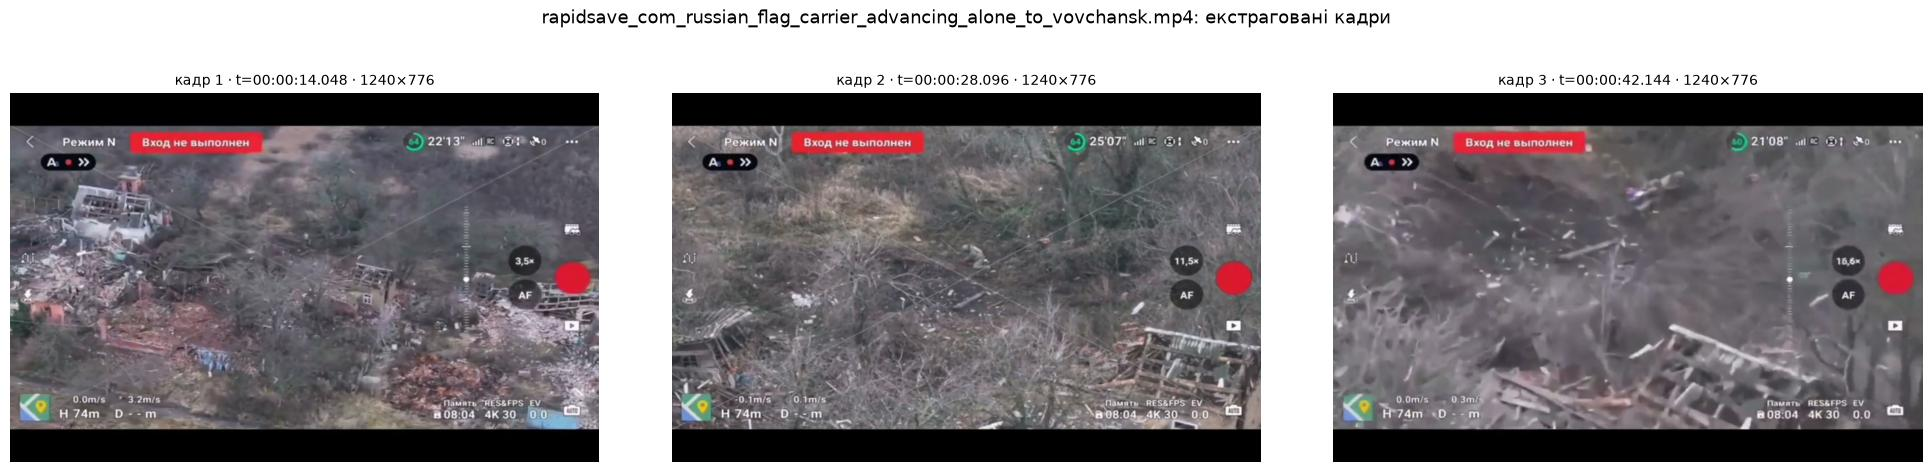

In [2]:
from osd.extract_frames import extract_frames
from osd.image_utils import show_images

frames = extract_frames(VIDEO_NAME, n_frames=C.N_FRAMES, max_side=C.MAX_SIDE, verbose=True)
show_images([f["image"] for f in frames],
            [f"кадр {f['index']} · t={f['timestamp']} · {f['width']}×{f['height']}" for f in frames],
            suptitle=f"{VIDEO_NAME}: екстраговані кадри")

## 3. Координатна сітка без падінгів

Сітка 0–1000 малюється прямо на кадрі (розмір не змінюється): напівпрозорі лінії кожні 100 + червоні цифри вздовж верхнього й лівого країв — лінійка для координат bbox.

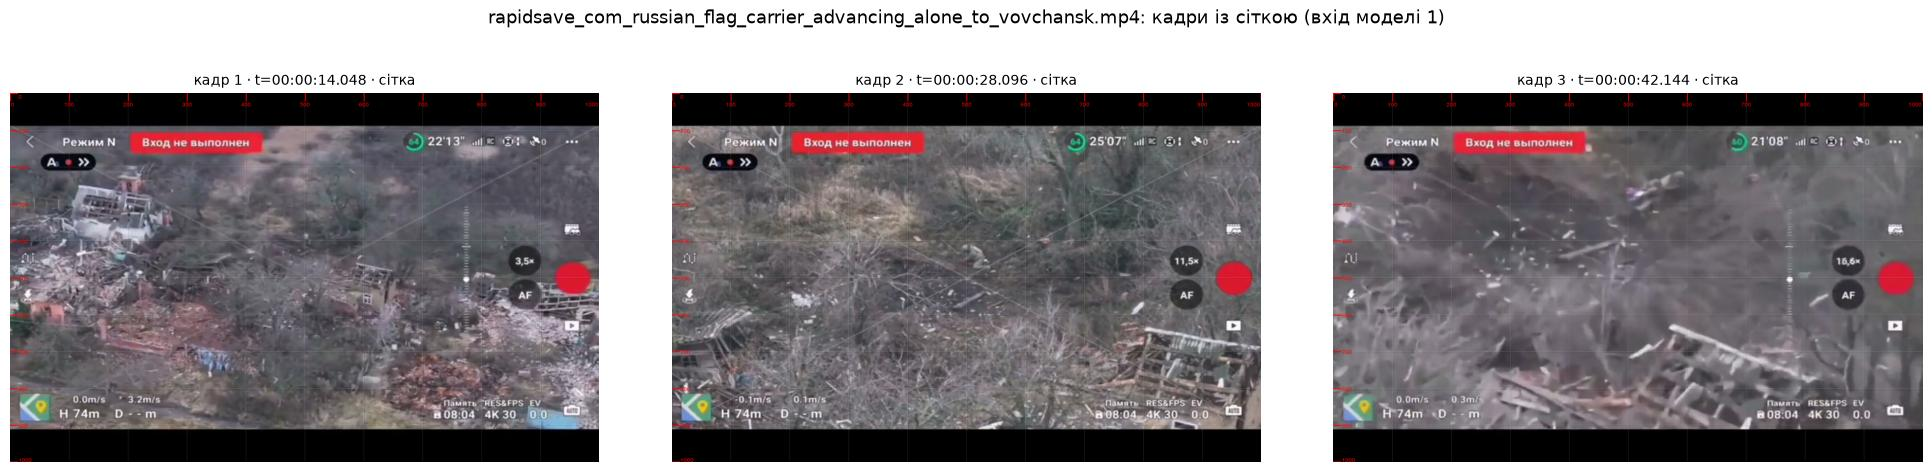

In [3]:
from osd.grid import overlay_grid_on_frames

grid_frames = overlay_grid_on_frames(frames)
show_images([f["grid_image"] for f in grid_frames],
            [f"кадр {f['index']} · t={f['timestamp']} · сітка" for f in grid_frames],
            suptitle=f"{VIDEO_NAME}: кадри із сіткою (вхід моделі 1)")

## 4. Вхід і промпт моделі 1

Кадри із сіткою → content (`<frame id timestamp>` + зображення). Повідомлення: **system** + **user** = інструкція → few-shot `<example>` (червоні рамки показують бажану гранулярність) → кадри відео. Нижче — повний промпт у порядку, в якому його бачить модель: текст дослівно, а кожне base64-зображення показане картинкою прямо на своєму місці в тексті.

📦 content моделі 1: 18 блоків, few-shot прикладів: 3, ~3.35 МБ
🧾 ПРОМПТ МОДЕЛІ 1 (детекція bbox): 2 повідомлення, 6096 символів тексту, 6 зображень

┏━━━━━━━━━━ [SYSTEM] ━━━━━━━━━━
You are a precise UI/OSD detector for game and camera footage.
You are given a VIDEO as an ordered sequence of frames: <frame id="N" timestamp="HH:MM:SS.mmm"> image </frame>.
Detect EVERY 2D overlay drawn on top of the video: interface elements, logos, watermarks, graphics — EXCEPT aiming/reticle (not needed for this task, never box it).
OSD elements include: hitmarker, health bar, armor bar, ammo counter, weapon icon, minimap, compass, kill feed, score, timer, team scores, chat, buttons, icons, damage indicator, status text, notifications, HUD panels, logo, watermark.
NOT OSD FOR THIS TASK — never box even if static and centered: aiming/reticle (crosshair, sight, aiming circle, aiming ticks/marks, center reticle, range marks).
Do NOT detect real-world objects, people, landscape, weapons in 3D scene — only 2

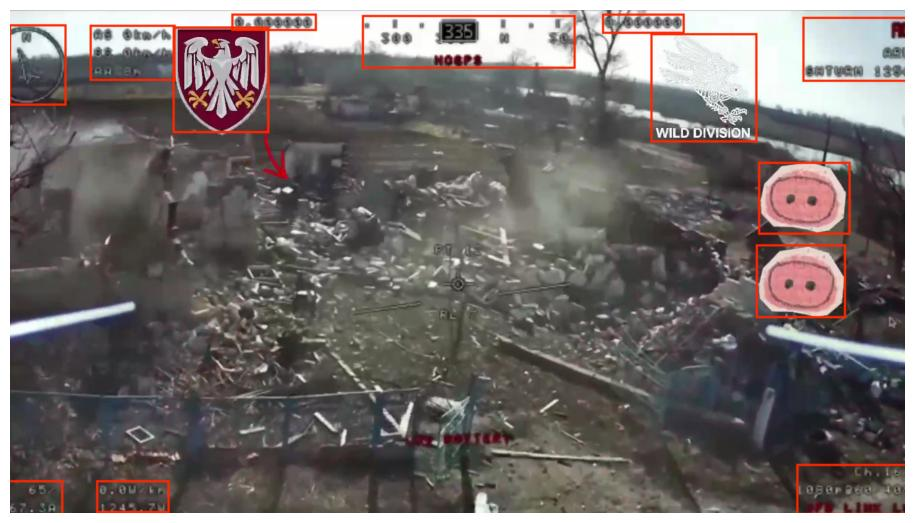

</example>
<example id="2">
[зображення 1920×1072]


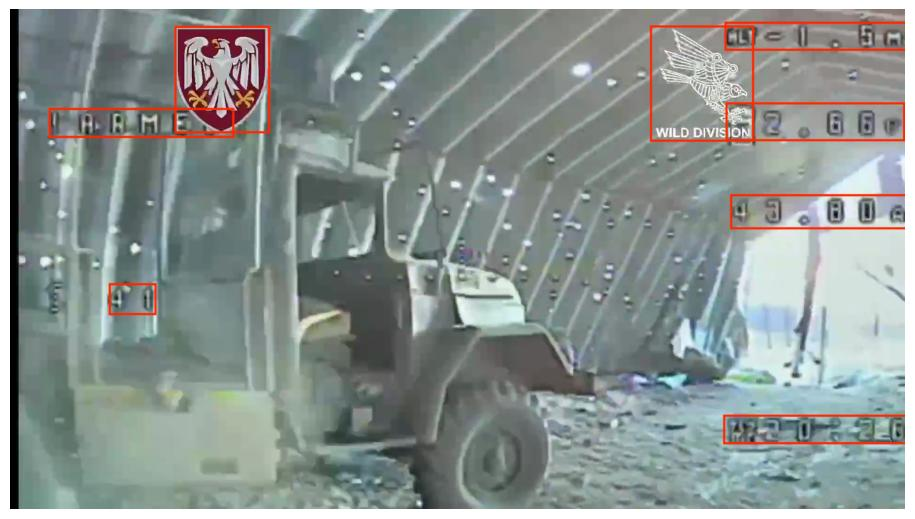

</example>
<example id="3">
[зображення 714×1280]


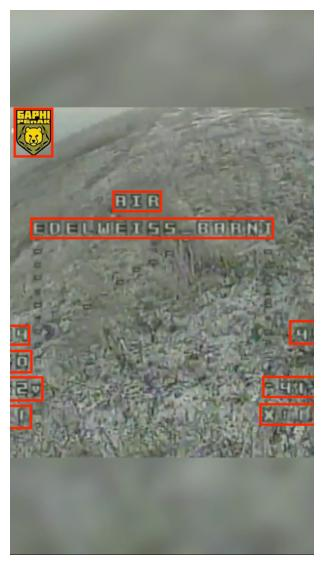

</example>
<frame id="1" timestamp="00:00:14.048">
[зображення 1240×776]


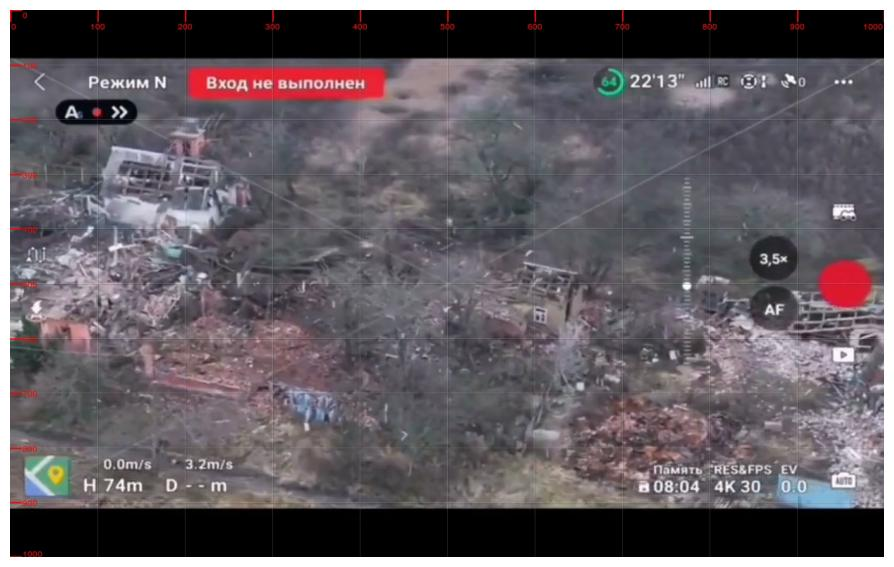

</frame>
<frame id="2" timestamp="00:00:28.096">
[зображення 1240×776]


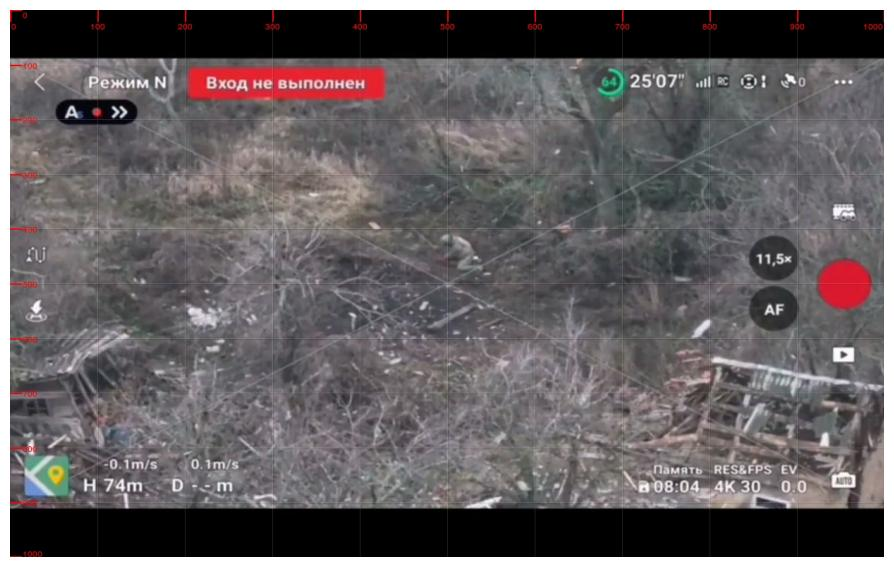

</frame>
<frame id="3" timestamp="00:00:42.144">
[зображення 1240×776]


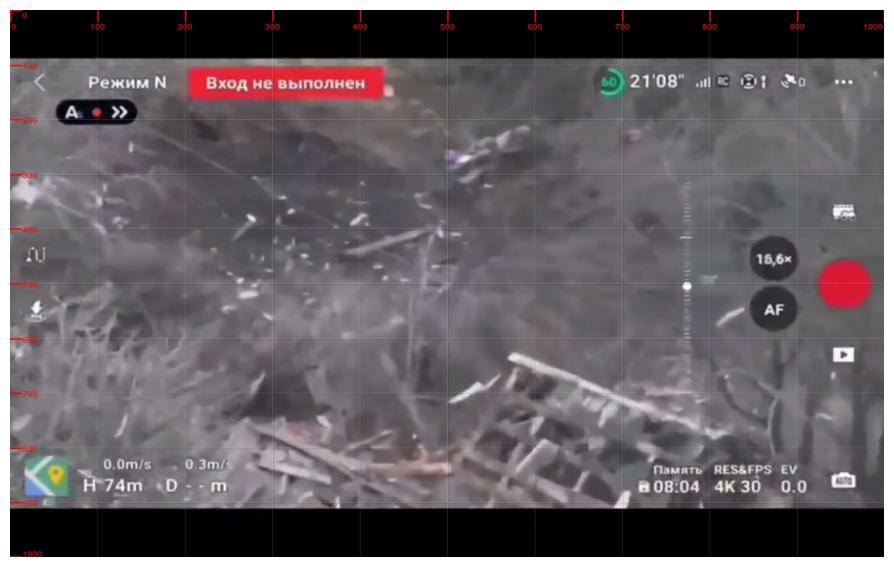

</frame>
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [4]:
from osd import prompt_model1
from osd.frames_to_content import estimate_content_mb, frames_to_content
from osd.viz_prompt import show_prompt

content_m1 = frames_to_content(grid_frames)
request_m1 = prompt_model1.build_messages(content_m1, n_frames=len(frames))
print(f"📦 content моделі 1: {len(request_m1['content'])} блоків, few-shot прикладів: "
      f"{request_m1['n_examples']}, ~{estimate_content_mb(request_m1['content'])} МБ")
show_prompt(request_m1, title="ПРОМПТ МОДЕЛІ 1 (детекція bbox)")

## 5. Модель 1: N паралельних запитів

Час і ціна кожного рану + середнє, далі кадри кожного рану з нанесеними bbox.

✅ ран #2: 53.5 c, $0.00287, спроб 1, повторів 429/5xx 0
✅ ран #4: 79.6 c, $0.00222, спроб 1, повторів 429/5xx 0
✅ ран #1: 85.4 c, $0.00276, спроб 1, повторів 429/5xx 0
✅ ран #3: 124.7 c, $0.00520, спроб 1, повторів 429/5xx 0
✅ ран #0: 163.5 c, $0.00369, спроб 1, повторів 429/5xx 1
📊 Модель 1 (bbox) · qwen/qwen3.8-flash (reasoning=low) · усі рани: успішних 5/5 · середній час 101.3 с · середня ціна $0.00335 · сума $0.01674


,ok,bbox,"час, с","останній запит, с","ціна, $",prompt tok,completion tok,reasoning tok,спроб,повторів 429/5xx,помилка
ран,,,,,,,,,,,
#0,✅,31,163.540,82.0910,0.003694,9354.0,7502.0,6841.0,1.0,1.0,
#1,✅,29,85.400,85.3980,0.002763,9354.0,5522.0,4956.0,1.0,0.0,
#2,✅,31,53.460,53.4520,0.002866,9354.0,3112.0,2507.0,1.0,0.0,
#3,✅,28,124.720,124.7230,0.005200,9354.0,10705.0,10173.0,1.0,0.0,
#4,✅,31,79.620,79.6170,0.002215,9354.0,4356.0,3763.0,1.0,0.0,
середнє,,None,101.348,85.0562,0.003348,9354.0,6239.4,5648.0,1.0,0.2,



===== ран моделі 1 #0 · 31 bbox · 163.5 с · $0.00369 =====


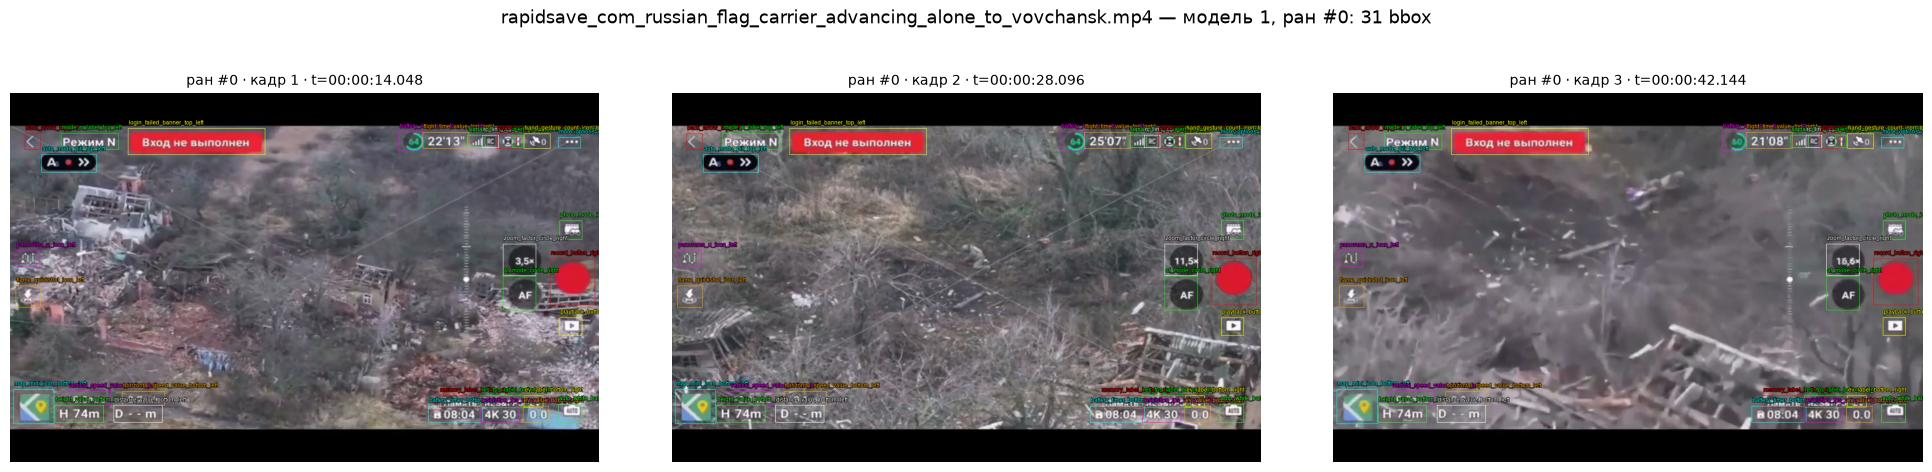


===== ран моделі 1 #1 · 29 bbox · 85.4 с · $0.00276 =====


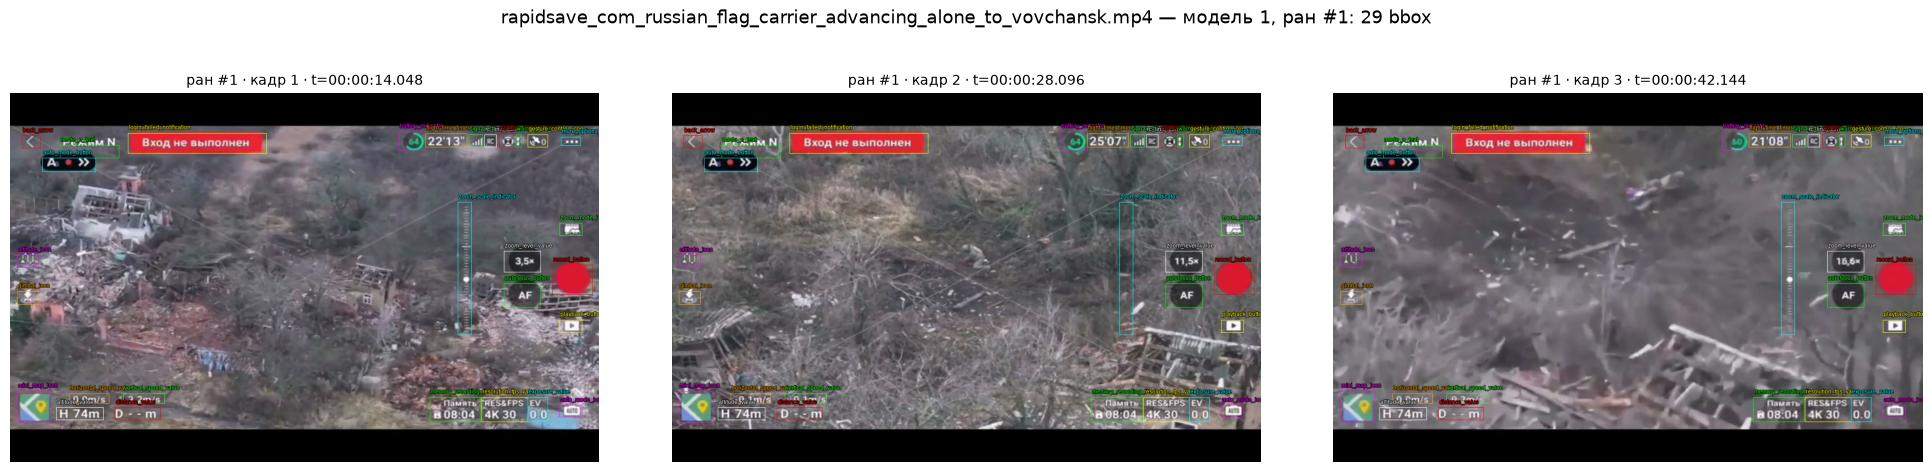


===== ран моделі 1 #2 · 31 bbox · 53.5 с · $0.00287 =====


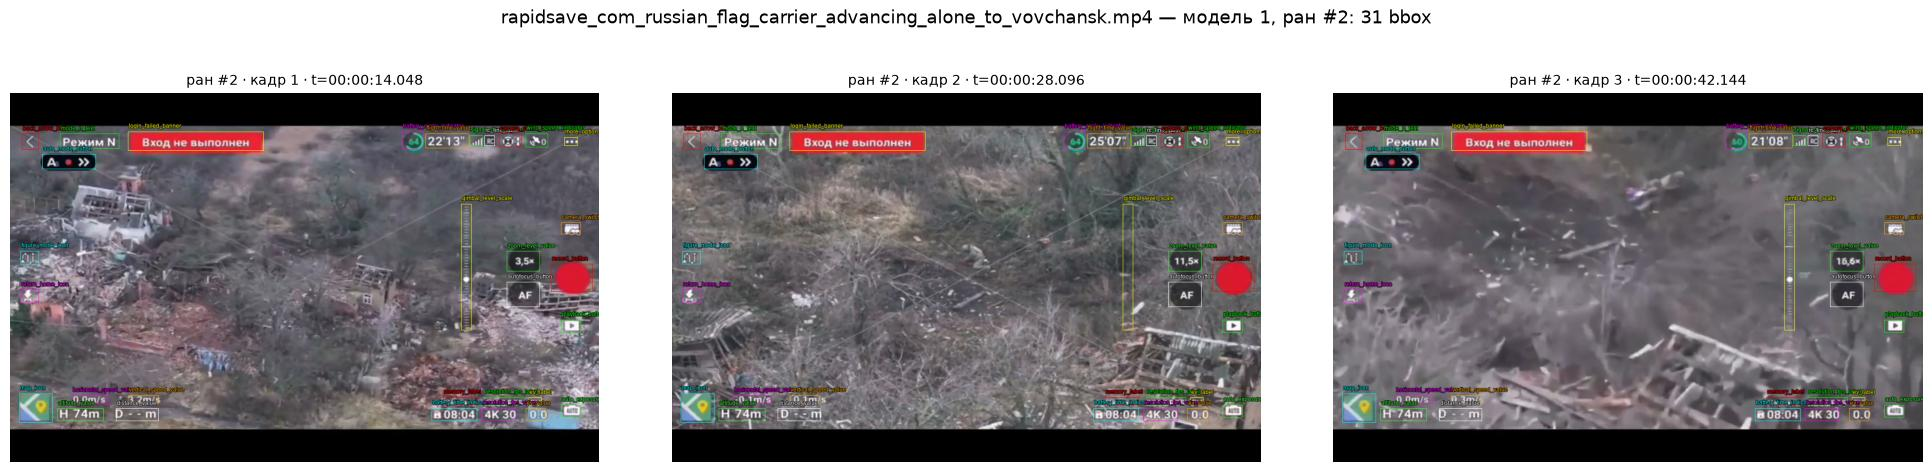


===== ран моделі 1 #3 · 28 bbox · 124.7 с · $0.00520 =====


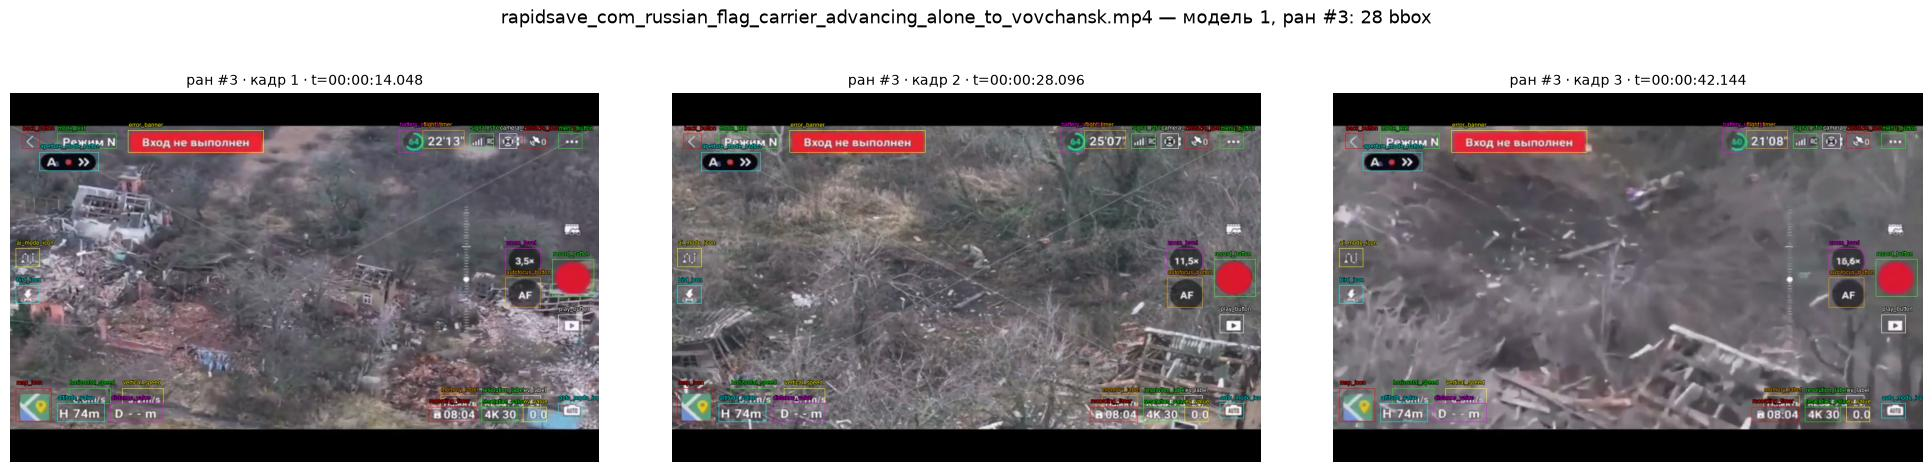


===== ран моделі 1 #4 · 31 bbox · 79.6 с · $0.00222 =====


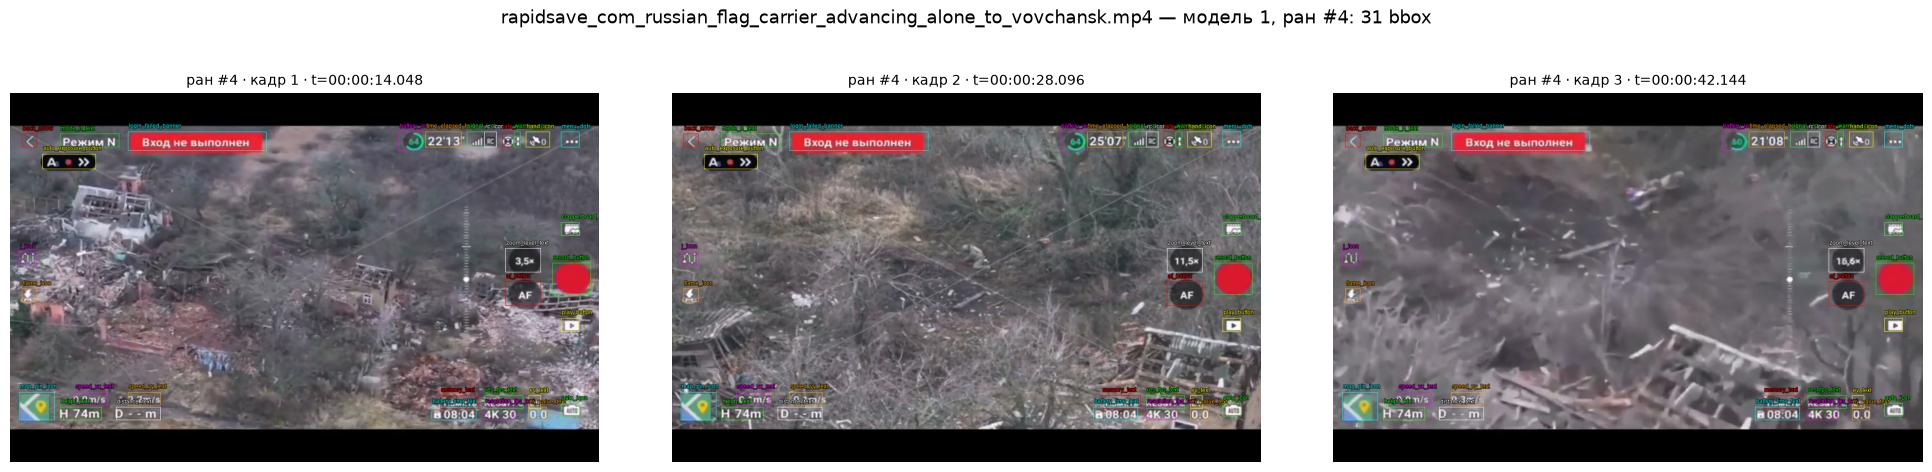

In [5]:
from osd.model1 import run_model1
from osd.viz_model1 import show_model1_runs

m1 = run_model1(request_m1, n_parallel=N_PARALLEL_M1, first_only=FIRST_ONLY, log=print)
show_model1_runs(frames, m1, video_name=VIDEO_NAME)

## 6. Вибір рану моделі 1 → промпт моделі 2

На чисті кадри наносяться bbox вибраного рану з непрозорістю `BBOX_OPACITY` (крізь рамки видно OSD). Моделі передаються три такі кадри + каталог назв bbox (без координат). Зображення показані прямо в тексті промпту.

➡️ у модель 2 йде ран моделі 1 #0: 31 bbox, opacity=0.5
🧾 ПРОМПТ МОДЕЛІ 2 (парсинг значень): 2 повідомлення, 6013 символів тексту, 3 зображень

┏━━━━━━━━━━ [SYSTEM] ━━━━━━━━━━
You read drone-video OSD (on-screen display) telemetry values.
You receive EXACTLY THREE frames (frame 0, 1, 2 in order). Each already has COLORED bounding boxes with NAMES drawn on it (e.g. top_left_altitude_value).
The user message also lists the EXACT box-name catalog from the previous detection stage — the set of keys and box NAMES is the SAME on all three frames, only values may differ across frames.
No coordinates are given to you — but bbox_name in your answer MUST match one name from the catalog EXACTLY (character-for-character, as written on the images). Never invent, rename, or rephrase a box name.
YOUR ONLY JOB: look at EVERY drawn box on ALL THREE frames and read the fixed keys below.
Fixed keys (output EVERY key exactly once, in this order):
- latitude: current aircraft position latitude
- longitude:

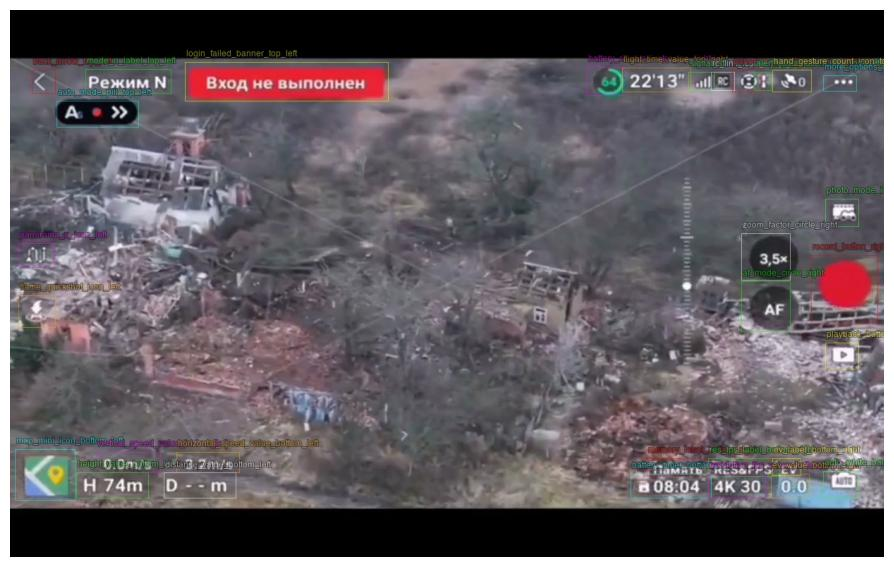

</frame>
<frame id="1">
[зображення 1240×776]


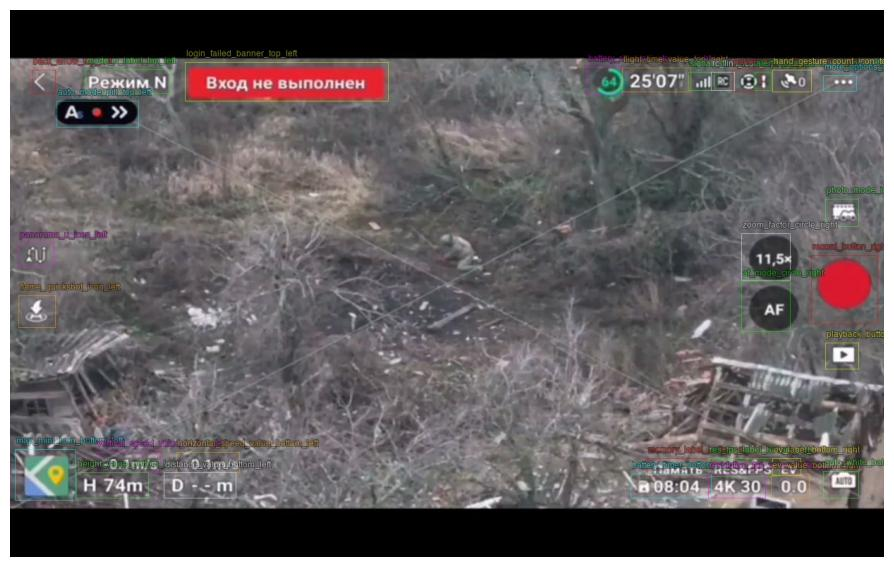

</frame>
<frame id="2">
[зображення 1240×776]


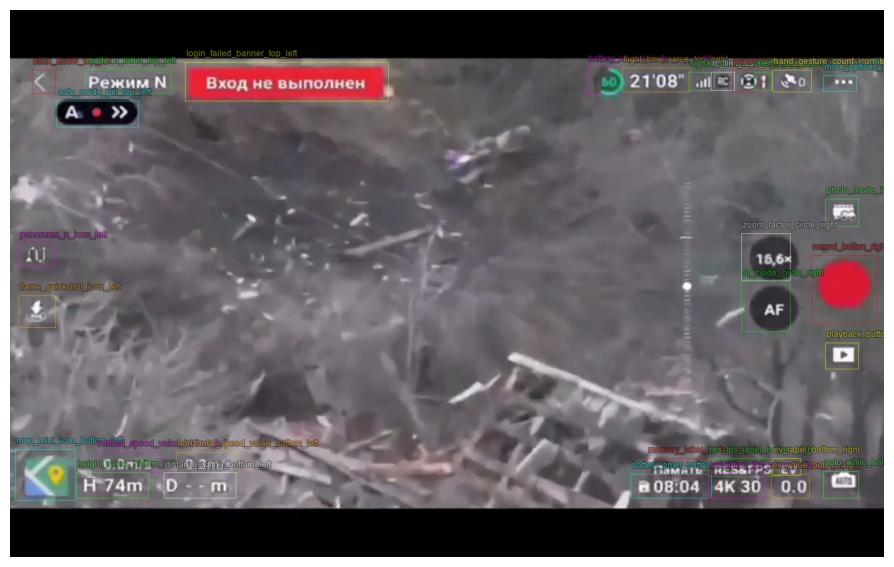

</frame>
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [6]:
from osd.model1 import select_run
from osd.model2 import prepare_model2_input

SELECTED_RUN_M1 = 0  # індекс рану моделі 1 (позиція в таблиці вище), який подається в модель 2

run_m1 = select_run(m1, SELECTED_RUN_M1)
prepared_m2 = prepare_model2_input(frames, run_m1["bboxes"], opacity=C.BBOX_OPACITY)
print(f"➡️ у модель 2 йде ран моделі 1 #{SELECTED_RUN_M1}: {len(run_m1['bboxes'])} bbox, "
      f"opacity={C.BBOX_OPACITY}")
show_prompt(prepared_m2["request"], title="ПРОМПТ МОДЕЛІ 2 (парсинг значень)")

## 7. Модель 2: N паралельних запитів

Час і ціна + середнє; для кожного рану — кадри лише з тими bbox, з яких зчитано значення, і таблиця словника відповіді без ключів, у яких усі значення `null`.

✅ ран #0: 162.7 c, $0.00602, спроб 1, повторів 429/5xx 0
⚠️ ран #1: parse: рядок 16: треба 5 полів, отримано 7: ['flight_time', '22\'13"', '25\'07"', '21\'08",flight_time_value_top_right\nosd_timer,08:04"', '08:04', '08:04', 'ba → спроба 2/3
✅ ран #2: 229.3 c, $0.00883, спроб 1, повторів 429/5xx 0
✅ ран #1: 292.9 c, $0.01168, спроб 2, повторів 429/5xx 0
📊 Модель 2 (значення) · qwen/qwen3.8-flash (reasoning=low) · усі рани: успішних 3/3 · середній час 228.3 с · середня ціна $0.00884 · сума $0.02652


,ok,ключів з даними,"час, с","останній запит, с","ціна, $",prompt tok,completion tok,reasoning tok,спроб,повторів 429/5xx,помилка
ран,,,,,,,,,,,
#0,✅,7,162.740000,162.738,0.006016,4380.0,12643.0,12332.0,1.000000,0.0,
#1,✅,7,292.890000,98.694,0.011682,8760.0,23301.0,22675.0,2.000000,0.0,
#2,✅,7,229.280000,229.278,0.008825,4380.0,18620.0,18303.0,1.000000,0.0,
середнє,,None,228.303333,163.570,0.008841,5840.0,18188.0,17770.0,1.333333,0.0,



===== ран моделі 2 #0 · OK · 162.7 с · $0.00602 =====
  bbox: 31 від моделі 1 → 7 зі значеннями


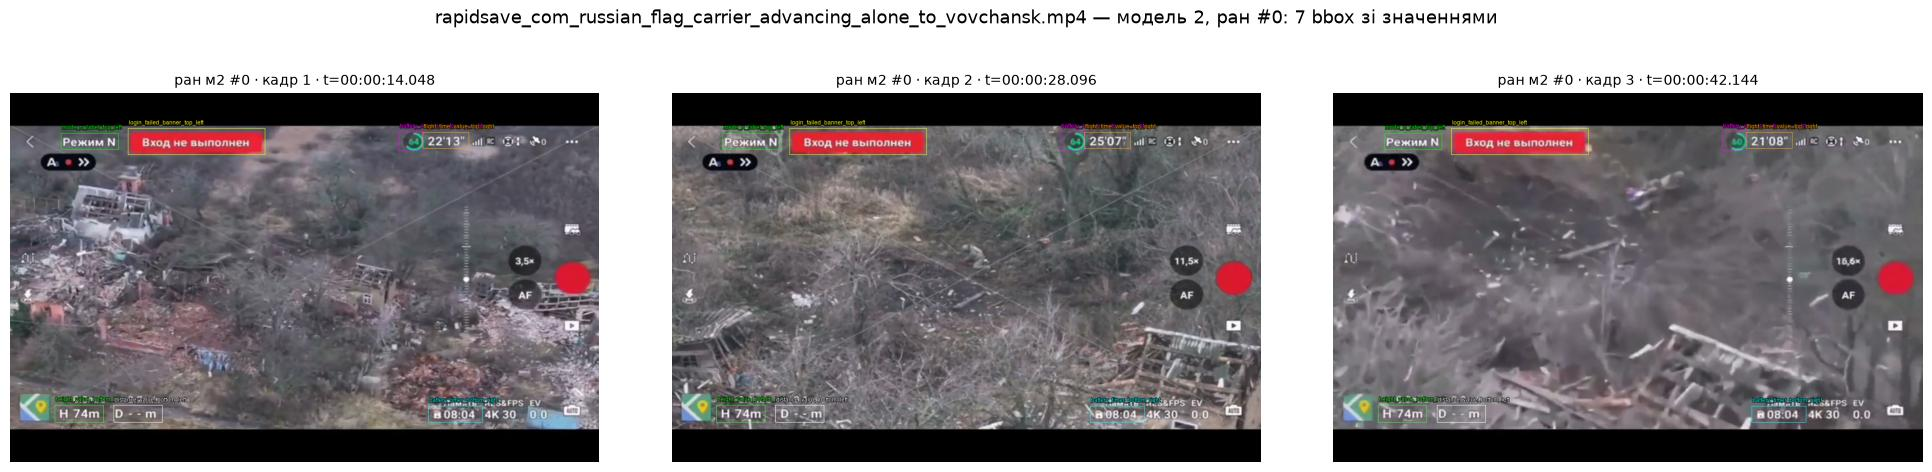

📋 словник рану #0 без all-null ключів: 7 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
altitude,H 74m,H 74m,H 74m,height_value_bottom_left
distance_to_home,D - - m,D - - m,D - - m,distance_value_bottom_left
flight_time,"22'13""","25'07""","21'08""",flight_time_value_top_right
osd_timer,08:04,08:04,08:04,battery_timer_bottom_right
flight_mode,Режим N,Режим N,Режим N,mode_n_label_top_left
battery_remaining_pct,64,64,60,battery_ring_indicator_top_right
warnings,Вход не выполнен,Вход не выполнен,Вход не выполнен,login_failed_banner_top_left



===== ран моделі 2 #1 · OK · 292.9 с · $0.01168 =====
  bbox: 31 від моделі 1 → 7 зі значеннями


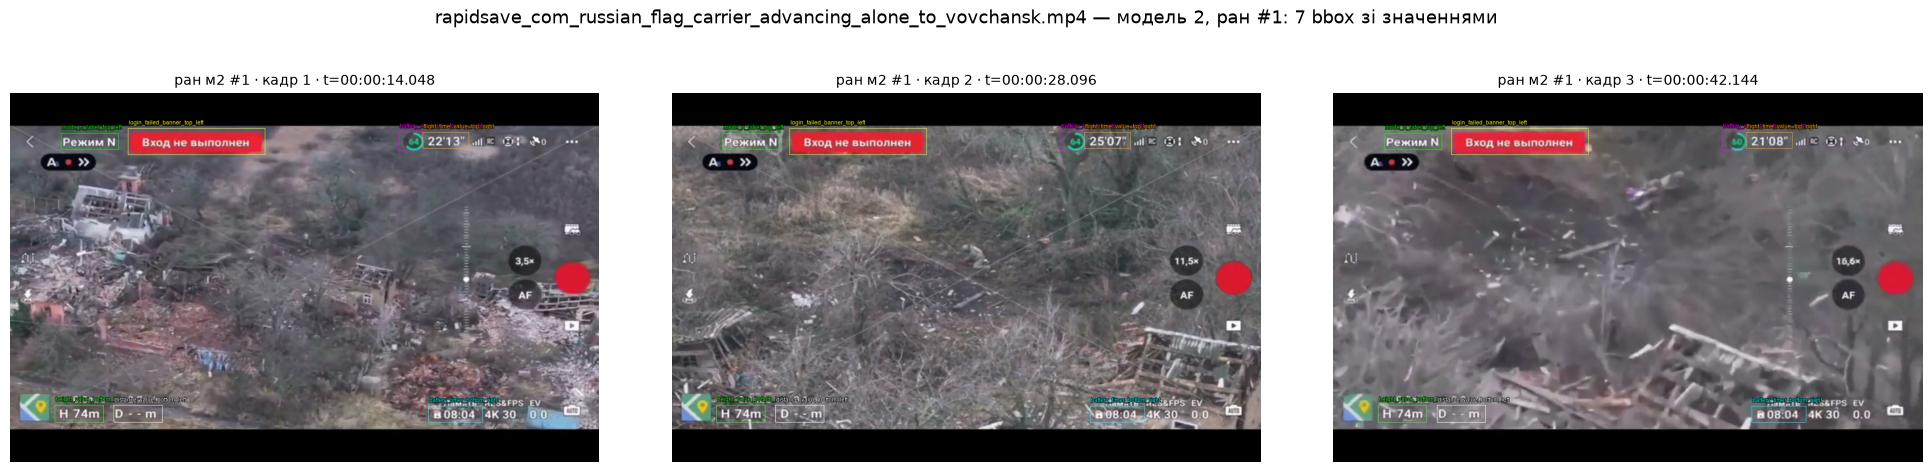

📋 словник рану #1 без all-null ключів: 7 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
altitude,H 74m,H 74m,H 74m,height_value_bottom_left
distance_to_home,D - - m,D - - m,D - - m,distance_value_bottom_left
flight_time,"22'13""","25'07""","21'08""",flight_time_value_top_right
osd_timer,08:04,08:04,08:04,battery_timer_bottom_right
flight_mode,Режим N,Режим N,Режим N,mode_n_label_top_left
battery_remaining_pct,64,64,60,battery_ring_indicator_top_right
warnings,Вход не выполнен,Вход не выполнен,Вход не выполнен,login_failed_banner_top_left



===== ран моделі 2 #2 · OK · 229.3 с · $0.00883 =====
  bbox: 31 від моделі 1 → 7 зі значеннями


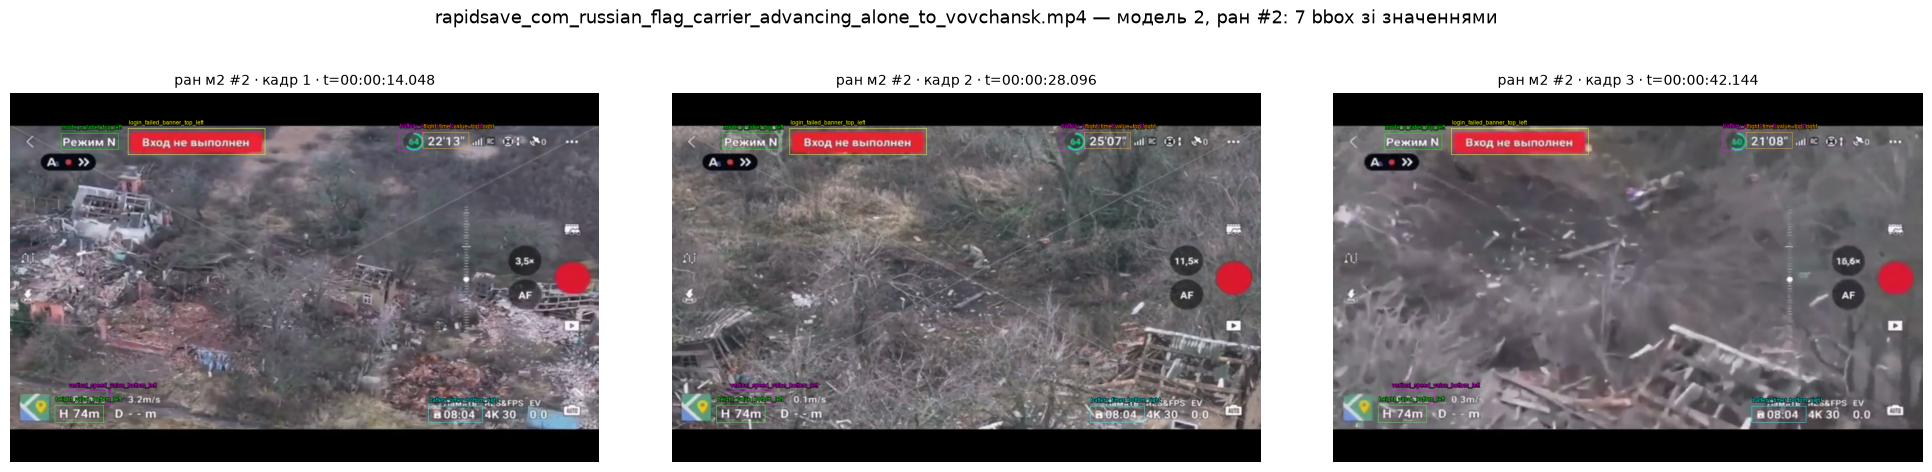

📋 словник рану #2 без all-null ключів: 7 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
altitude,H 74m,H 74m,H 74m,height_value_bottom_left
vertical_speed,V:0 m/s,V:0 m/s,V:0 m/s,vertical_speed_value_bottom_left
flight_time,"22'13""","25'07""","21'08""",flight_time_value_top_right
osd_timer,08:04,08:04,08:04,battery_timer_bottom_right
flight_mode,Режим N,Режим N,Режим N,mode_n_label_top_left
battery_remaining_pct,64,64,60,battery_ring_indicator_top_right
warnings,Вход не выполнен,Вход не выполнен,Вход не выполнен,login_failed_banner_top_left


In [7]:
from osd.model2 import run_model2
from osd.viz_model2 import show_model2_runs

m2 = run_model2(prepared_m2, n_parallel=N_PARALLEL_M2, first_only=FIRST_ONLY, log=print)
show_model2_runs(frames, m2, run_m1["bboxes"], video_name=VIDEO_NAME)

## 8. Повні результати

Середні ціна й час за виклики моделі 1 і моделі 2; по рядку на кадр: **оригінал | bbox моделі 1 | bbox моделі 2**; внизу — словник моделі 2 без ключів, у яких усі значення `null`.

🎬 rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk.mp4 · bbox: модель 1 = 31, модель 2 = 7 · ран м1 #0, ран м2 #0


,модель,ранів,успішних,"середній час, с","середня ціна, $"
виклик,,,,,
модель 1 (bbox),qwen/qwen3.8-flash (low),5,5,101.35,0.003348
модель 2 (значення),qwen/qwen3.8-flash (low),3,3,228.30,0.008841
разом (м1 + м2),,8,8,329.65,0.012189


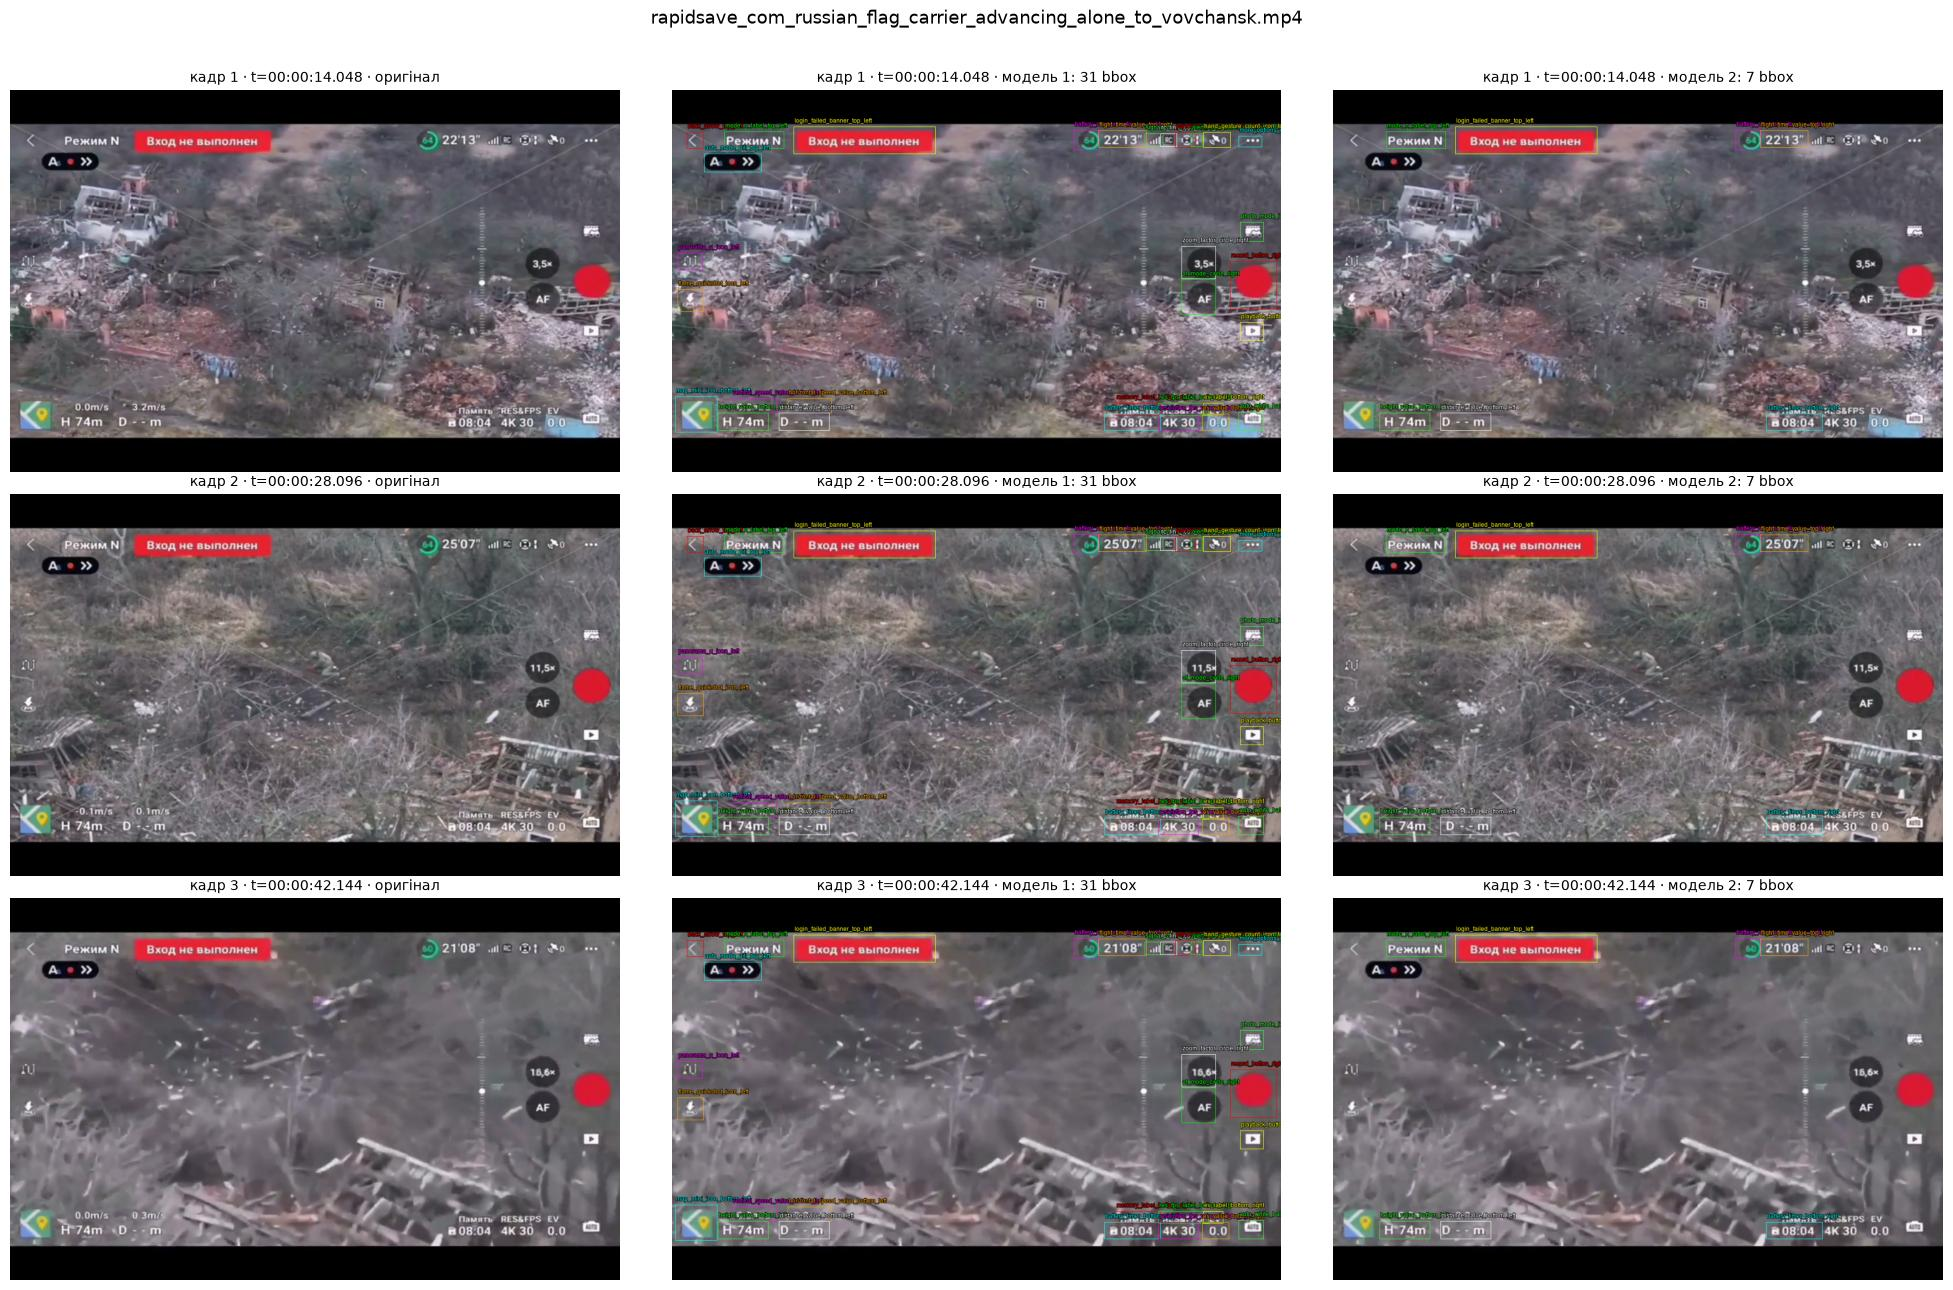

📋 словник моделі 2 без all-null ключів: 7 з 25 ключів


,value_0,value_1,value_2,bbox_name
key,,,,
altitude,H 74m,H 74m,H 74m,height_value_bottom_left
distance_to_home,D - - m,D - - m,D - - m,distance_value_bottom_left
flight_time,"22'13""","25'07""","21'08""",flight_time_value_top_right
osd_timer,08:04,08:04,08:04,battery_timer_bottom_right
flight_mode,Режим N,Режим N,Режим N,mode_n_label_top_left
battery_remaining_pct,64,64,60,battery_ring_indicator_top_right
warnings,Вход не выполнен,Вход не выполнен,Вход не выполнен,login_failed_banner_top_left


In [8]:
from osd.pipeline import assemble_result
from osd.viz_results import show_results

SELECTED_RUN_M2 = 0  # індекс рану моделі 2 для візуалізації

select_run(m2, SELECTED_RUN_M2)  # перевірка, що ран успішний
result = assemble_result(VIDEO_NAME, frames, m1, m2, SELECTED_RUN_M1, SELECTED_RUN_M2)
show_results(result);

## 9. Відео з bbox

OSD статичний, тож bbox накладаються на кожен кадр відео. Повні mp4 (H.264) зберігаються в `outputs/videos/`; тут — GIF-прев'ю (GitHub не відтворює відео в ноутбуках).

💾 outputs/videos/rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk_m1_bbox.mp4
💾 outputs/videos/rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk_m2_bbox.mp4
модель 1: 31 bbox · rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk_m1_bbox.mp4: 1152×720, 56.2 с, 30.0 fps · GIF прискорено ×7.5
🎞️ rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk_m1_bbox.gif: 1048 KB


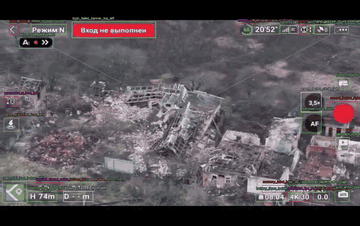

модель 2: 7 bbox (лише зі значеннями) · rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk_m2_bbox.mp4: 1152×720, 56.2 с, 30.0 fps · GIF прискорено ×7.5
🎞️ rapidsave_com_russian_flag_carrier_advancing_alone_to_vovchansk_m2_bbox.gif: 1049 KB


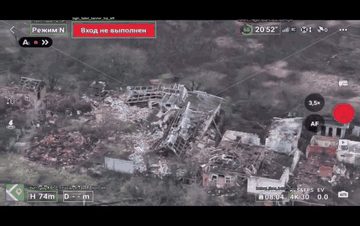

In [9]:
from osd.bbox_video import render_bbox_video

video_m1 = render_bbox_video(VIDEO_NAME, result["m1_bboxes"], suffix="m1_bbox")
video_m2 = render_bbox_video(VIDEO_NAME, result["m2_bboxes"], reference_bboxes=result["m1_bboxes"],
                             suffix="m2_bbox")
print(f"💾 {video_m1.relative_to(ROOT)}\n💾 {video_m2.relative_to(ROOT)}")
show_video_gif(video_m1, caption=f"модель 1: {len(result['m1_bboxes'])} bbox")
show_video_gif(video_m2, caption=f"модель 2: {len(result['m2_bboxes'])} bbox (лише зі значеннями)");